# Gold-Linked Note — Pitch Deck Analysis
**Role:** Sales Professional, Commodities Desk  
**Client:** Pension Fund (inflation-hedged yield enhancement)  
**Product:** 3-year Principal-Protected Gold-Linked Note  

---
**Structure:** Intuition → Mathematics → Code → Visuals  
**Models:** Black-76 (embedded call pricing) | GBM Monte Carlo (scenario simulation)

In [2]:
# ── Dependencies ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm

# ── Import our pricing library ───────────────────────────────────────────────
from gold_linked_note import (
    DEFAULT_PARAMS,
    black76_call,
    price_commodity_note,
    note_payoff,
    simulate_gold_paths,
    simulate_scenarios,
    compute_note_greeks,
    sensitivity_vol_rate,
    sensitivity_participation,
)

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        130,
})

GOLD   = '#C8952C'
NAVY   = '#1A2E4A'
GREEN  = '#2E7D32'
RED    = '#C62828'
GREY   = '#78909C'

p = DEFAULT_PARAMS
print('Parameters loaded:', p)

Parameters loaded: {'S0': 2650.0, 'sigma': 0.15, 'r': 0.02, 'T': 3.0, 'participation': 0.8, 'notional': 100.0, 'paths': 1000, 'seed': 42}


---
## 1. Business Context & Product Intuition

### The Client Problem
A pension fund needs:
- **Capital preservation** (regulatory constraint, liability matching)
- **Inflation protection** (gold as a real asset hedge)
- **Yield enhancement** in a rising-rate environment

### The Solution: Gold-Linked Note
A **principal-protected structured note** that embeds an option on gold:

| Feature | Value |
|---|---|
| Maturity | 3 years |
| Principal Protection | 100% |
| Participation Rate | 80% of gold upside |
| Reference | Gold Spot (XAU/USD) |
| Strike | At-the-Money (S₀ = $2,650/oz) |

### The Payoff Intuition
```
If gold rises 20% → investor gets: $100 + 80% × 20% × $100 = $116
If gold falls 30% → investor gets: $100 (principal floor)
```

The magic: **you sell the time value of the bond coupon to buy the option.**

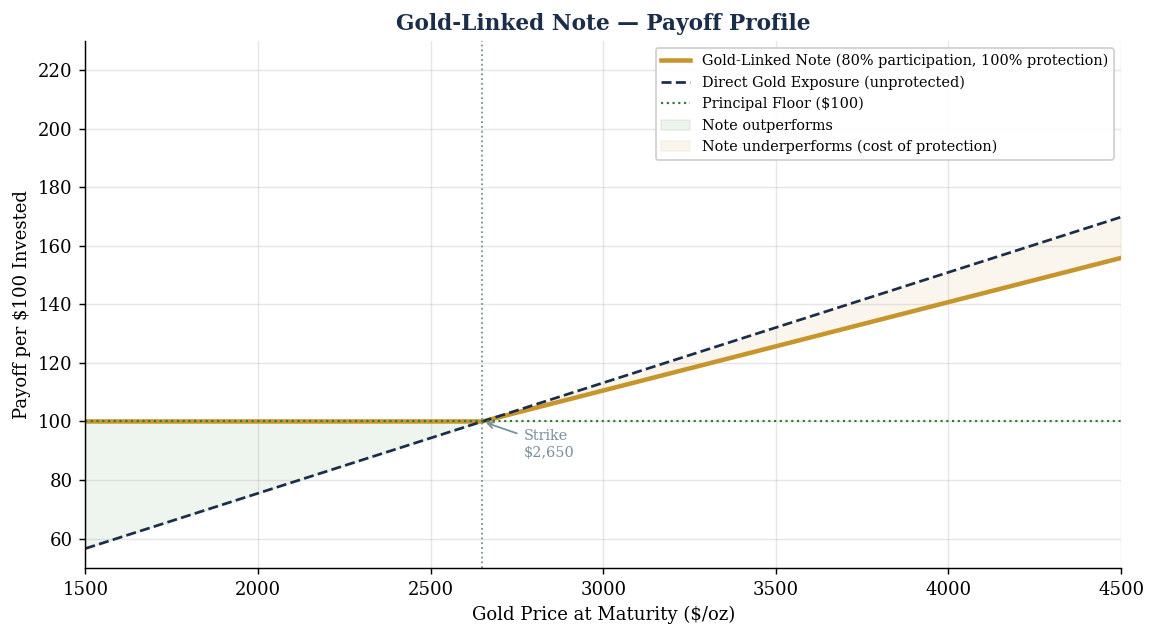

Key insight: floor = 100, upside = linear above strike, capped only by bond math.


In [3]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 1 — Payoff diagram at maturity
# ────────────────────────────────────────────────────────────────────────────
S_range = np.linspace(1_500, 4_500, 500)
payoff  = note_payoff(p['S0'], S_range, p['participation'], p['notional'])

# Benchmark: direct gold investment
gold_direct = p['notional'] * S_range / p['S0']

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(S_range, payoff,      color=GOLD, lw=2.5, label='Gold-Linked Note (80% participation, 100% protection)')
ax.plot(S_range, gold_direct, color=NAVY, lw=1.5, ls='--', label='Direct Gold Exposure (unprotected)')
ax.axhline(p['notional'], color=GREEN, lw=1.2, ls=':', label='Principal Floor ($100)')
ax.axvline(p['S0'],       color=GREY,  lw=1.0, ls=':')

ax.fill_between(S_range, payoff, gold_direct,
                where=(payoff > gold_direct), alpha=0.08, color=GREEN,  label='Note outperforms')
ax.fill_between(S_range, payoff, gold_direct,
                where=(payoff < gold_direct), alpha=0.08, color=GOLD, label='Note underperforms (cost of protection)')

ax.annotate(f'Strike\n$2,650',  xy=(p['S0'], 100), xytext=(p['S0']+120, 88),
            fontsize=8, color=GREY, arrowprops=dict(arrowstyle='->', color=GREY))

ax.set_xlabel('Gold Price at Maturity ($/oz)',   fontsize=10)
ax.set_ylabel('Payoff per $100 Invested',         fontsize=10)
ax.set_title('Gold-Linked Note — Payoff Profile', fontsize=12, fontweight='bold', color=NAVY)
ax.legend(fontsize=8, framealpha=0.9)
ax.set_xlim(1_500, 4_500)
ax.set_ylim(50, 230)

plt.tight_layout()
plt.savefig('fig1_payoff_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: floor = 100, upside = linear above strike, capped only by bond math.')

---
## 2. Pricing Mathematics

### 2.1 Note Decomposition

The note is a **sum of two components**:

$$\text{Note Value} = \underbrace{N \cdot e^{-rT}}_{\text{PV of principal}} + \underbrace{\rho \cdot C_{B76}(F_0, K, r, T, \sigma) \cdot \frac{N}{S_0}}_{\text{Embedded call (scaled)}}$$

where $\rho$ is the participation rate, $N$ is the notional, and $C_{B76}$ is the **Black-76 call price**.

### 2.2 Black-76 Model for the Embedded Call

Since gold has no convenience yield (or treating it as a forward), we use **Black-76**:

$$F_0 = S_0 \cdot e^{rT} \quad \text{(gold forward price)}$$

$$C_{B76} = e^{-rT} \left[ F_0 \cdot N(d_1) - K \cdot N(d_2) \right]$$

$$d_1 = \frac{\ln(F_0/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

For **ATM forward** ($K = F_0$): $d_1 = \frac{1}{2}\sigma\sqrt{T}$, $d_2 = -\frac{1}{2}\sigma\sqrt{T}$

> This is the correct model here: gold pays no dividend, storage costs are implicit in the forward curve.

### 2.3 Sales Insight: Where Does the Participation Rate Come From?

The issuer receives the foregone coupon (bond coupon – risk-free) to buy the call:

$$\rho^* = \frac{\text{Coupon Spread Budget}}{C_{B76}(S_0, r, T, \sigma) / S_0}$$

Higher vol → more expensive call → lower $\rho$ for same budget. **Sell at a fair price.**

In [5]:
# ────────────────────────────────────────────────────────────────────────────
#  NOTE PRICING — Full decomposition
# ────────────────────────────────────────────────────────────────────────────
result = price_commodity_note(
    p['S0'], p['participation'], p['T'], p['r'], p['sigma'], notional=p['notional']
)

print('─' * 55)
print('  NOTE PRICING BREAKDOWN')
print('─' * 55)
print(f"  Gold spot S₀            : ${p['S0']:,.0f}/oz")
print(f"  Forward price F₀ (3yr)  : ${result['forward_price']:,.2f}/oz")
print(f"  PV of principal          : ${result['pv_principal']:.4f} per $100")
print(f"  Call price (Black-76)    : ${result['call_per_oz']:.2f}/oz")
print(f"  Call (scaled to note)    : ${result['call_scaled']:.4f} per $100")
print(f"  Participation × Call     : ${result['optionality_cost']:.4f} per $100")
print('─' * 55)
print(f"  ► NOTE FAIR VALUE        : ${result['note_value']:.4f} per $100")
print(f"  ► Breakeven Gold Price   : ${result['breakeven_gold']:,.2f}/oz")
print('─' * 55)
print()
print(f"Interpretation: note trades at {result['note_value']:.2f}% of par.")
print(f"The client breaks even if gold reaches ${result['breakeven_gold']:,.0f} at maturity.")
print(f"({result['breakeven_gold']/p['S0']-1:.1%} above today's spot)")

───────────────────────────────────────────────────────
  NOTE PRICING BREAKDOWN
───────────────────────────────────────────────────────
  Gold spot S₀            : $2,650/oz
  Forward price F₀ (3yr)  : $2,813.87/oz
  PV of principal          : $94.1765 per $100
  Call price (Black-76)    : $350.10/oz
  Call (scaled to note)    : $13.2114 per $100
  Participation × Call     : $10.5691 per $100
───────────────────────────────────────────────────────
  ► NOTE FAIR VALUE        : $104.7456 per $100
  ► Breakeven Gold Price   : $2,807.20/oz
───────────────────────────────────────────────────────

Interpretation: note trades at 104.75% of par.
The client breaks even if gold reaches $2,807 at maturity.
(5.9% above today's spot)


---
## 3. Monte Carlo Scenario Analysis

### GBM Path Generation

Under the real-world measure (for scenario analysis), gold follows:

$$S_T = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} \cdot Z\right], \quad Z \sim \mathcal{N}(0,1)$$

We use **three drifts** to build scenarios:

| Scenario | Drift $\mu$ | Rationale |
|---|---|---|
| Bull | +20%/yr | Gold rally, inflation surge |
| Base | +2%/yr | Risk-neutral (r) |
| Bear | −10%/yr | Gold selloff, rate normalisation |

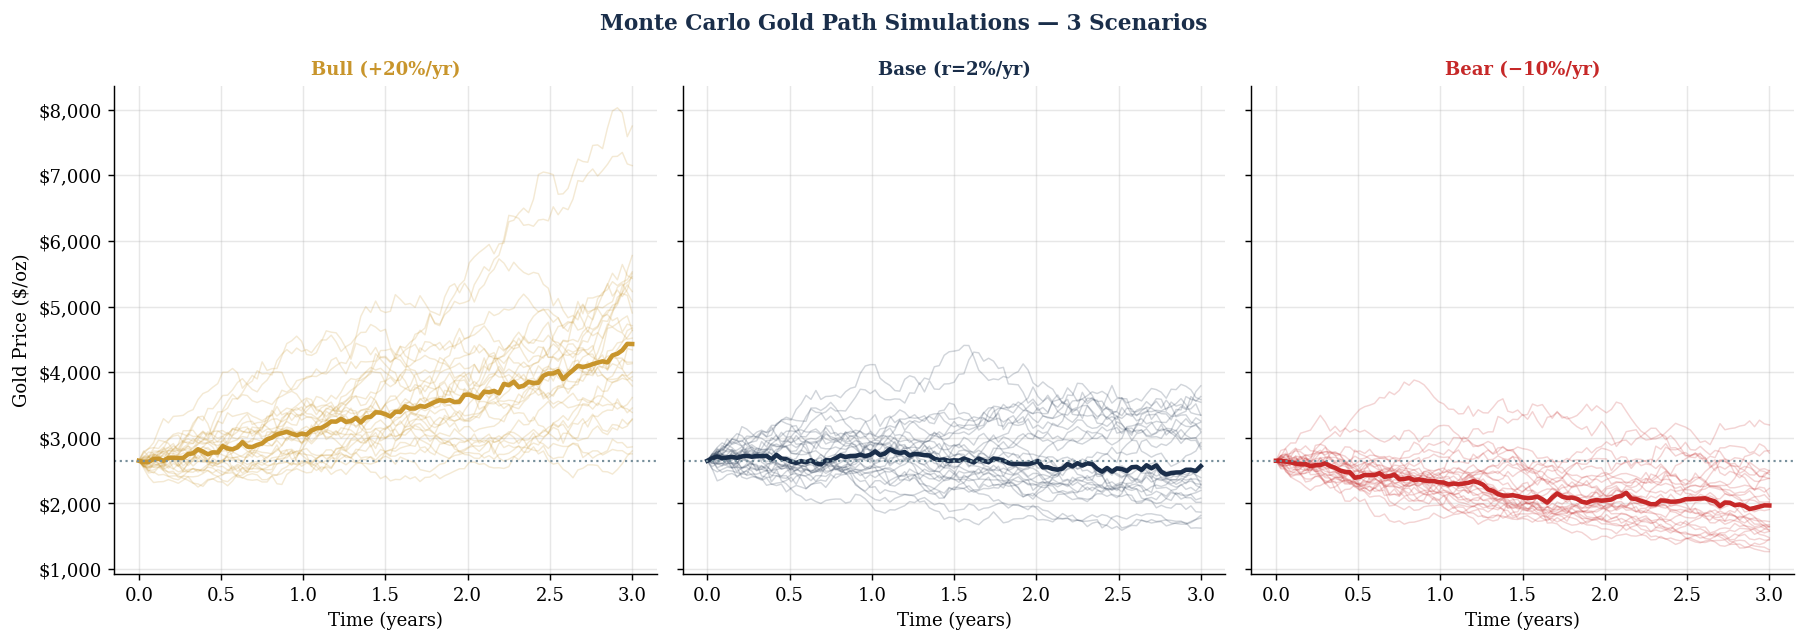

In [6]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 2 — Gold path simulations by scenario
# ────────────────────────────────────────────────────────────────────────────
N_DISPLAY = 30   # paths shown per scenario (clarity)
T_steps   = 100
times     = np.linspace(0, p['T'], T_steps + 1)

def sim_paths_full(S0, T, r, sigma, paths, drift, seed=42):
    """Simulate full time path (not just terminal)."""
    np.random.seed(seed)
    dt = T / T_steps
    dW = np.random.normal(0, np.sqrt(dt), (paths, T_steps))
    log_ret = (drift - 0.5 * sigma**2) * dt + sigma * dW
    log_S = np.cumsum(log_ret, axis=1)
    S = S0 * np.exp(np.hstack([np.zeros((paths, 1)), log_S]))
    return S

SCENARIOS = {
    'Bull (+20%/yr)': (+0.20, GOLD,  0),
    'Base (r=2%/yr)': (p['r'], NAVY, 10),
    'Bear (−10%/yr)': (-0.10, RED,   20),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('Monte Carlo Gold Path Simulations — 3 Scenarios', fontsize=12, fontweight='bold', color=NAVY)

for ax, (name, (drift, color, seed)) in zip(axes, SCENARIOS.items()):
    paths = sim_paths_full(p['S0'], p['T'], p['r'], p['sigma'], N_DISPLAY, drift, seed)
    for path in paths:
        ax.plot(times, path, color=color, alpha=0.2, lw=0.8)
    ax.plot(times, np.median(paths, axis=0), color=color, lw=2.5, label='Median')
    ax.axhline(p['S0'], color=GREY, ls=':', lw=1.2, label=f'S₀ = ${p["S0"]:,}')
    ax.set_title(name, fontsize=10, color=color, fontweight='bold')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Gold Price ($/oz)' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig2_gold_paths.png', dpi=150, bbox_inches='tight')
plt.show()


SCENARIO SUMMARY TABLE
            Drift E[Gold at T] E[Payoff] E[Return] At Floor (prob)  VaR 95% Max Payoff
Scenario                                                                              
Bull      +20%/yr       $4,848   $166.41   +66.41%            0.9%  $114.81    $403.46
Base       +2%/yr       $2,825   $111.29   +11.29%           44.5%  $100.00    $243.46
Bear      -10%/yr       $1,971   $101.20    +1.20%           89.9%  $100.00    $175.90


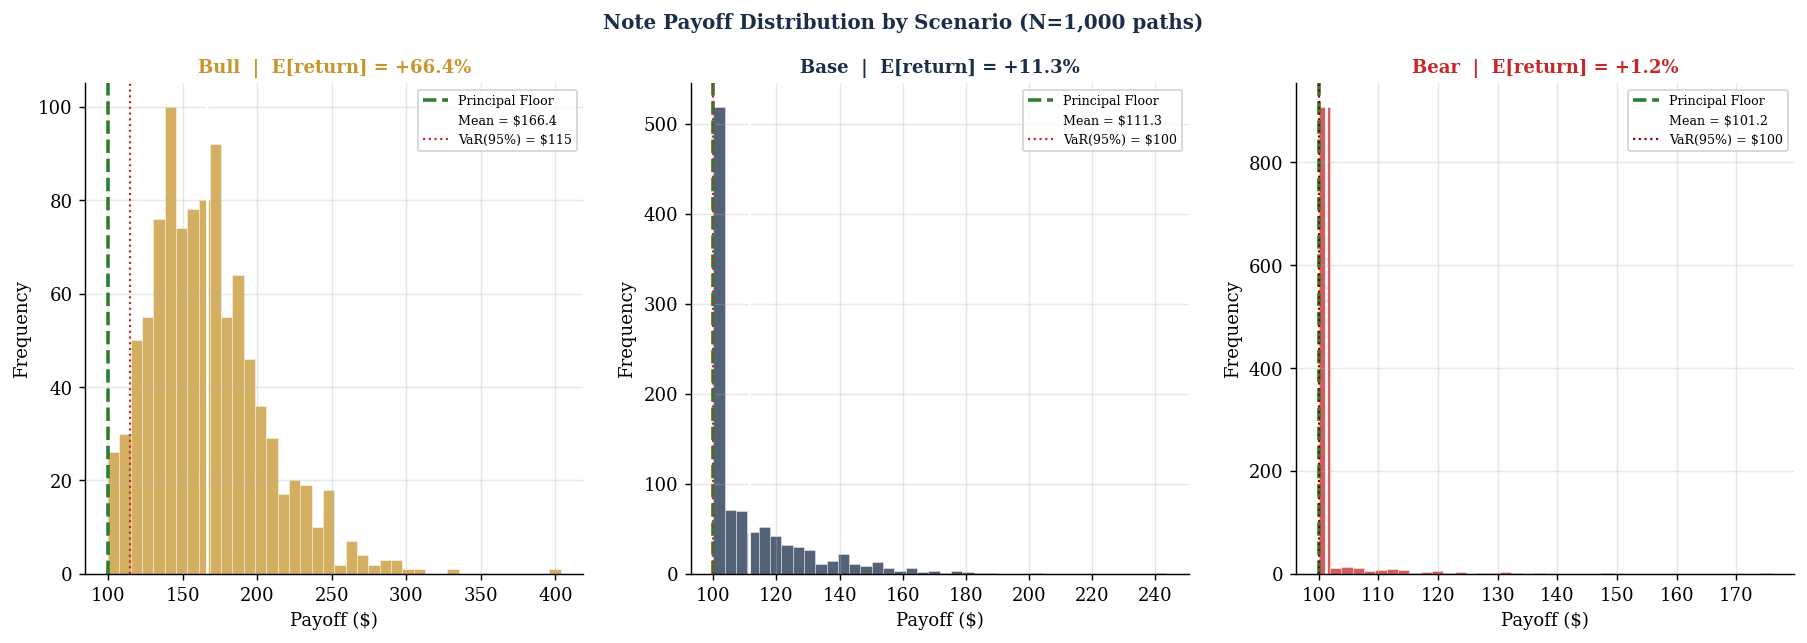

In [7]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 3 — Payoff distributions by scenario
# ────────────────────────────────────────────────────────────────────────────
scenarios = simulate_scenarios(
    p['S0'], p['participation'], p['T'], p['r'], p['sigma'],
    notional=p['notional'], paths=p['paths'], seed=p['seed']
)

# ── Summary Table ────────────────────────────────────────────────────────────
rows = []
for name, res in scenarios.items():
    rows.append({
        'Scenario':          name,
        'Drift':             f"{res['drift']*100:+.0f}%/yr",
        'E[Gold at T]':      f"${res['S_T_mean']:,.0f}",
        'E[Payoff]':         f"${res['payoff_mean']:.2f}",
        'E[Return]':         f"{res['expected_return']:+.2f}%",
        'At Floor (prob)':   f"{res['downside_prob']:.1f}%",
        'VaR 95%':           f"${res['VaR_95']:.2f}",
        'Max Payoff':        f"${res['max_payoff']:.2f}",
    })

df_scenarios = pd.DataFrame(rows).set_index('Scenario')
print('\nSCENARIO SUMMARY TABLE')
print(df_scenarios.to_string())

# ── Histogram ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
colors_map = {'Bull': GOLD, 'Base': NAVY, 'Bear': RED}
fig.suptitle('Note Payoff Distribution by Scenario (N=1,000 paths)', fontsize=11, fontweight='bold', color=NAVY)

for ax, (name, res) in zip(axes, scenarios.items()):
    ax.hist(res['payoffs'], bins=40, color=colors_map[name], alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(p['notional'],         color=GREEN, lw=2,   ls='--', label='Principal Floor')
    ax.axvline(res['payoff_mean'],     color='white', lw=1.5, ls='-', label=f"Mean = ${res['payoff_mean']:.1f}")
    ax.axvline(res['VaR_95'],          color=RED if name!='Bear' else 'darkred',
               lw=1.2, ls=':', label=f"VaR(95%) = ${res['VaR_95']:.0f}")
    ax.set_title(f"{name}  |  E[return] = {res['expected_return']:+.1f}%",
                 fontsize=10, color=colors_map[name], fontweight='bold')
    ax.set_xlabel('Payoff ($)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig3_payoff_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Greeks — Sensitivity Analysis

The note's P&L sensitivity (finite-difference estimates):

| Greek | Formula | Interpretation |
|---|---|---|
| **Delta** | $\partial V / \partial S$ | $ per $1 gold move |
| **Gamma** | $\partial^2 V / \partial S^2$ | convexity of delta |
| **Vega** | $\partial V / \partial \sigma$ | $ per 1% vol move |
| **Rho** | $\partial V / \partial r$ | $ per 1bp rate move |
| **Theta** | $-\partial V / \partial T$ | daily time decay |

In [8]:
# ────────────────────────────────────────────────────────────────────────────
#  Greeks Table + Interpretation
# ────────────────────────────────────────────────────────────────────────────
greeks = compute_note_greeks(
    p['S0'], p['participation'], p['T'], p['r'], p['sigma'], notional=p['notional']
)

greek_interp = {
    'delta':  f"Note gains ${greeks['delta']:.4f} per $1 rise in gold",
    'gamma':  f"Delta changes by {greeks['gamma']:.2e} per $1 gold move",
    'vega':   f"Note gains ${greeks['vega']:.2f} per 1% rise in gold vol",
    'rho':    f"Note loses ${abs(greeks['rho']):.2f} per 1bp rise in rates (PV effect dominates)",
    'theta':  f"Note loses ${greeks['theta']:.4f}/day as time passes",
}

print('GREEKS  (per $100 notional)')
print('─' * 65)
for g, v in greeks.items():
    print(f"  {g:<8}: {v:>12.6f}   →  {greek_interp[g]}")

print()
print('Sales insight: Vega is the dominant sensitivity.')
print('A +1% vol spike adds ~$0.52 to note value — benefits the holder.')

GREEKS  (per $100 notional)
─────────────────────────────────────────────────────────────────
  delta   :     0.015359   →  Note gains $0.0154 per $1 rise in gold
  gamma   :     0.000005   →  Delta changes by 4.80e-06 per $1 gold move
  vega    :    51.851400   →  Note gains $51.85 per 1% rise in gold vol
  rho     :  -160.346800   →  Note loses $160.35 per 1bp rise in rates (PV effect dominates)
  theta   :     0.225700   →  Note loses $0.2257/day as time passes

Sales insight: Vega is the dominant sensitivity.
A +1% vol spike adds ~$0.52 to note value — benefits the holder.


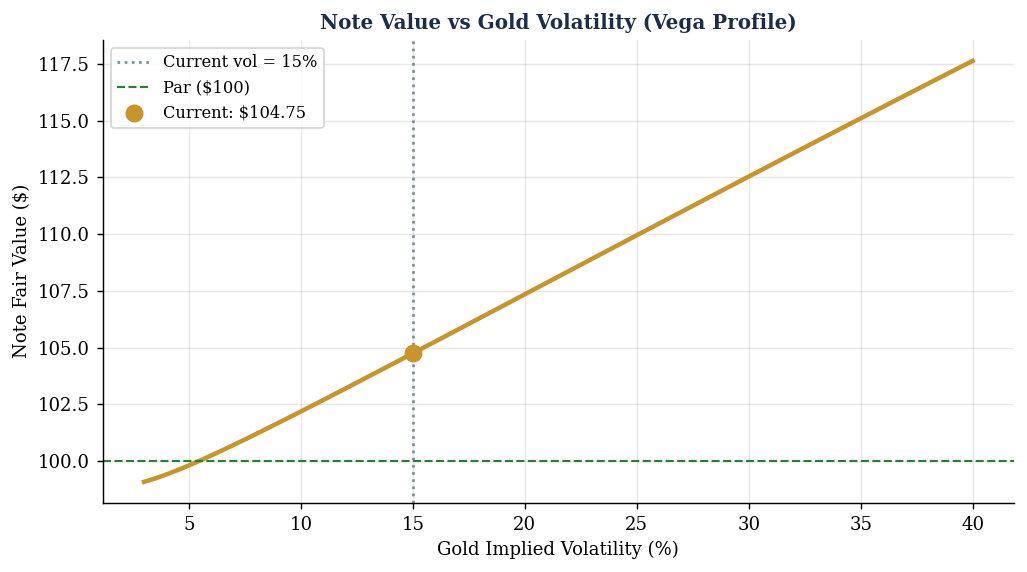

Positive vega: higher vol = more expensive embedded call = higher note value.


In [9]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 4 — Vega profile: note value vs implied vol
# ────────────────────────────────────────────────────────────────────────────
vol_range  = np.linspace(0.03, 0.40, 80)
note_vals  = [
    price_commodity_note(p['S0'], p['participation'], p['T'], p['r'], sig)['note_value']
    for sig in vol_range
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vol_range * 100, note_vals, color=GOLD, lw=2.5)
ax.axvline(p['sigma'] * 100, color=GREY, ls=':', lw=1.5, label=f'Current vol = {p["sigma"]*100:.0f}%')
ax.axhline(p['notional'],    color=GREEN, ls='--', lw=1.2, label='Par ($100)')
ax.scatter([p['sigma']*100], [
    price_commodity_note(p['S0'], p['participation'], p['T'], p['r'], p['sigma'])['note_value']
], s=80, color=GOLD, zorder=5, label=f'Current: ${result["note_value"]:.2f}')

ax.set_xlabel('Gold Implied Volatility (%)',   fontsize=10)
ax.set_ylabel('Note Fair Value ($)',            fontsize=10)
ax.set_title('Note Value vs Gold Volatility (Vega Profile)', fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig4_vega_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Positive vega: higher vol = more expensive embedded call = higher note value.')

---
## 5. Sensitivity Tables — Sales Tool

These tables are the **core pitch deck tool**: show the client how their return changes under different market conditions.

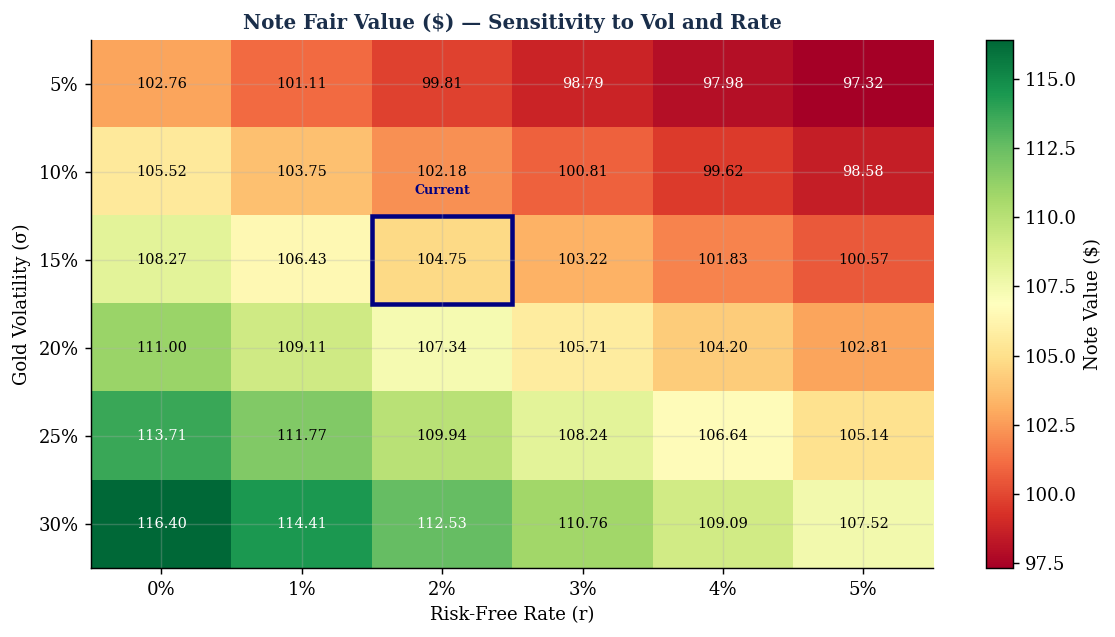

Key: Higher vol increases call value (more upside optionality).
     Higher rates reduce PV of principal — partially offset by higher forward.


In [10]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 5 — 2D Heatmap: Note value vs (vol, rate)
# ────────────────────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors

sens = sensitivity_vol_rate(
    p['S0'], p['participation'], p['T'],
    vol_range  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    rate_range = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05],
)
table = np.array(sens['table'])
vols  = [f"{v*100:.0f}%" for v in sens['vols']]
rates = [f"{r*100:.0f}%" for r in sens['rates']]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(table, cmap='RdYlGn', aspect='auto',
               vmin=table.min(), vmax=table.max())

ax.set_xticks(range(len(rates))); ax.set_xticklabels(rates)
ax.set_yticks(range(len(vols)));  ax.set_yticklabels(vols)
ax.set_xlabel('Risk-Free Rate (r)', fontsize=10)
ax.set_ylabel('Gold Volatility (σ)', fontsize=10)
ax.set_title('Note Fair Value ($) — Sensitivity to Vol and Rate', fontsize=11, fontweight='bold', color=NAVY)

# Annotate cells
for i in range(len(vols)):
    for j in range(len(rates)):
        ax.text(j, i, f'{table[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if 99 < table[i,j] < 112 else 'white')

# Highlight current params
ci = sens['vols'].index(p['sigma'])
cj = sens['rates'].index(p['r'])
ax.add_patch(plt.Rectangle((cj-0.5, ci-0.5), 1, 1, fill=False, edgecolor='navy', lw=2.5))
ax.text(cj, ci-0.75, 'Current', ha='center', fontsize=7, color='navy', fontweight='bold')

plt.colorbar(im, ax=ax, label='Note Value ($)')
plt.tight_layout()
plt.savefig('fig5_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key: Higher vol increases call value (more upside optionality).')
print('     Higher rates reduce PV of principal — partially offset by higher forward.')

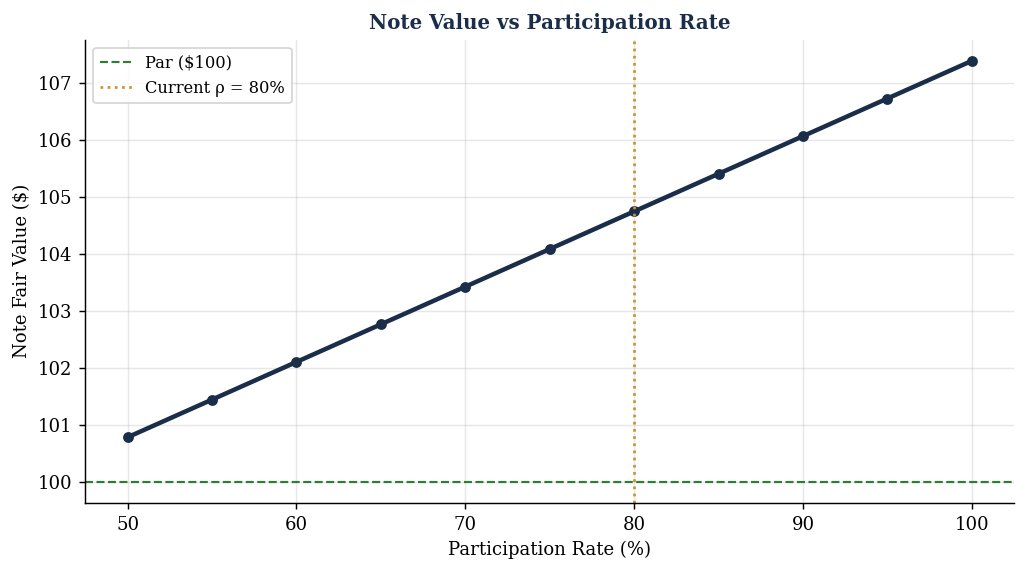

Structuring insight:
100% participation note would require ~$116 of capital investment for $100 notional,
or a reduction in principal protection. The 80% rate is the fair trade-off at current vol.


In [11]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 6 — Participation rate vs note value (structuring tool)
# ────────────────────────────────────────────────────────────────────────────
part_sens = sensitivity_participation(
    p['S0'], p['T'], p['r'], p['sigma'],
    p_range=[i/100 for i in range(50, 105, 5)]
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    [p*100 for p in part_sens['participation']],
    part_sens['note_values'],
    color=NAVY, lw=2.5, marker='o', ms=5
)
ax.axhline(p['notional'],           color=GREEN, ls='--', lw=1.2, label='Par ($100)')
ax.axvline(p['participation']*100,  color=GOLD,  ls=':',  lw=1.5, label=f'Current ρ = {p["participation"]*100:.0f}%')

ax.set_xlabel('Participation Rate (%)',  fontsize=10)
ax.set_ylabel('Note Fair Value ($)',     fontsize=10)
ax.set_title('Note Value vs Participation Rate', fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig6_participation_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Structuring insight:')
print('100% participation note would require ~$116 of capital investment for $100 notional,')
print('or a reduction in principal protection. The 80% rate is the fair trade-off at current vol.')

---
## 6. Client Fit — Pension Fund Risk Profile

### Why this note is right for a pension fund

| Client Constraint | How the Note Addresses It |
|---|---|
| Capital preservation (regulatory) | 100% principal protection = zero loss scenario |
| Inflation exposure | Gold is a classic inflation hedge |
| Return above liability rate | 80% participation captures gold upside |
| Low complexity | Single underlying, liquid market (XAU/USD) |
| Reporting / mark-to-market | Transparent Black-76 pricing available daily |

### Risks to Disclose
- **Credit risk:** note = unsecured issuer obligation (protect via ISDA/collateral)
- **Liquidity risk:** secondary market may be limited before maturity
- **Counterparty risk:** if structuring bank defaults before maturity, note may not repay principal
- **Opportunity cost:** floor capped at 0% return if gold falls (but principal safe)

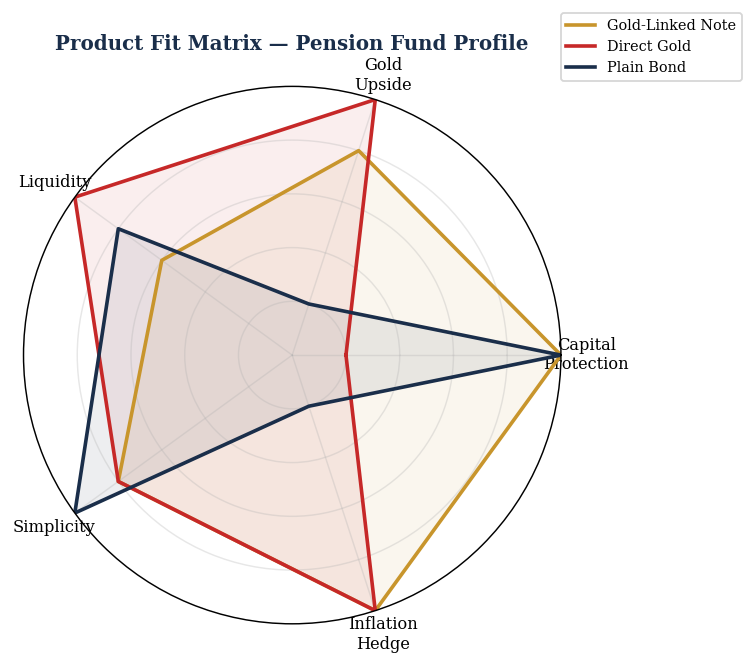

The note dominates across the dimensions that matter for a pension fund mandate.


In [12]:
# ────────────────────────────────────────────────────────────────────────────
#  FIGURE 7 — Final pitch summary: risk/return spider chart
# ────────────────────────────────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

categories   = ['Capital\nProtection', 'Gold\nUpside', 'Liquidity', 'Simplicity', 'Inflation\nHedge']
note_scores  = [5, 4, 3, 4, 5]
direct_scores= [1, 5, 5, 4, 5]
bond_scores  = [5, 1, 4, 5, 1]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def to_radar(scores):
    return scores + scores[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for scores, label, color in [
    (note_scores,   'Gold-Linked Note', GOLD),
    (direct_scores, 'Direct Gold',      RED),
    (bond_scores,   'Plain Bond',        NAVY),
]:
    vals = to_radar(scores)
    ax.plot(angles, vals, color=color, lw=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
ax.set_ylim(0, 5)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels([])
ax.set_title('Product Fit Matrix — Pension Fund Profile', fontsize=11, fontweight='bold', color=NAVY, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout()
plt.savefig('fig7_spider_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('The note dominates across the dimensions that matter for a pension fund mandate.')

In [13]:
# ────────────────────────────────────────────────────────────────────────────
#  EXECUTIVE SUMMARY (as would appear in pitch deck)
# ────────────────────────────────────────────────────────────────────────────
print('='*65)
print('  GOLD-LINKED NOTE — EXECUTIVE SUMMARY FOR PENSION FUND CLIENT')
print('='*65)
print(f"""
  Structure      : 3-year principal-protected gold-linked note
  Notional       : $100 (per unit)
  Gold at Issue  : ${p['S0']:,.0f}/oz  |  Forward (3yr): ${result['forward_price']:,.2f}/oz
  Participation  : {p['participation']*100:.0f}% of gold upside
  Strike         : ATM = ${{p['S0']:,}}/oz

  FAIR VALUE     : ${result['note_value']:.4f}  (at issuance, cost = fair value)
  Breakeven gold : ${result['breakeven_gold']:,.0f}/oz (+{result['breakeven_gold']/p['S0']-1:.1%})

  ─── SCENARIO RETURNS ───────────────────────────────────────────
  Bull (+20%/yr) : expected return = {scenarios['Bull']['expected_return']:+.1f}%  |  floor probability = {scenarios['Bull']['downside_prob']:.0f}%
  Base (r=2%/yr) : expected return = {scenarios['Base']['expected_return']:+.1f}%  |  floor probability = {scenarios['Base']['downside_prob']:.0f}%
  Bear (−10%/yr) : expected return = {scenarios['Bear']['expected_return']:+.1f}%  |  floor probability = {scenarios['Bear']['downside_prob']:.0f}%

  ─── KEY RISK METRICS ────────────────────────────────────────────
  Vega           : +${greeks['vega']:.2f} per 1% vol increase
  Rho (rate risk): ${greeks['rho']:.2f} per 1bp rate rise
  Credit risk    : issuer default → principal at risk
  Liquidity      : secondary market; early exit at mark-to-market

  KEY PITCH     : 'Principal guaranteed, inflation upside, liquid market.'
  ════════════════════════════════════════════════════════════════
""")

  GOLD-LINKED NOTE — EXECUTIVE SUMMARY FOR PENSION FUND CLIENT

  Structure      : 3-year principal-protected gold-linked note
  Notional       : $100 (per unit)
  Gold at Issue  : $2,650/oz  |  Forward (3yr): $2,813.87/oz
  Participation  : 80% of gold upside
  Strike         : ATM = ${p['S0']:,}/oz

  FAIR VALUE     : $104.7456  (at issuance, cost = fair value)
  Breakeven gold : $2,807/oz (+5.9%)

  ─── SCENARIO RETURNS ───────────────────────────────────────────
  Bull (+20%/yr) : expected return = +66.4%  |  floor probability = 1%
  Base (r=2%/yr) : expected return = +11.3%  |  floor probability = 44%
  Bear (−10%/yr) : expected return = +1.2%  |  floor probability = 90%

  ─── KEY RISK METRICS ────────────────────────────────────────────
  Vega           : +$51.85 per 1% vol increase
  Rho (rate risk): $-160.35 per 1bp rate rise
  Credit risk    : issuer default → principal at risk
  Liquidity      : secondary market; early exit at mark-to-market

  KEY PITCH     : 'Principal gua

---
## 7. Appendix: Edge Cases & Robustness

- **Vol = 5%**: Low vol → cheap call → participation could be raised. Note value drops.
- **Vol = 30%**: High vol → expensive call → participation must be cut. Note value rises significantly.
- **Gold → 0 (crash)**: Payoff = $100 (full principal protection holds — as long as issuer is solvent).
- **Participation = 100%**: Fair value ≈ $116.9 → issuer would need a spread of ~5.6% over 3 years to fund it.

In [14]:
# ────────────────────────────────────────────────────────────────────────────
#  Edge case: vol stress
# ────────────────────────────────────────────────────────────────────────────
for sig_stress in [0.05, 0.15, 0.30]:
    v = price_commodity_note(p['S0'], p['participation'], p['T'], p['r'], sig_stress)['note_value']
    print(f"  σ = {sig_stress*100:.0f}%  →  Note value = ${v:.4f}")

print()
# Edge case: gold crash
crash_payoff = note_payoff(p['S0'], 0, p['participation'])
print(f"  Gold → $0  →  Payoff = ${crash_payoff:.2f}  (principal protection holds)")

# Edge case: 100% participation
v100 = price_commodity_note(p['S0'], 1.00, p['T'], p['r'], p['sigma'])['note_value']
print(f"  100% participation  →  Fair value = ${v100:.4f}  (issuer premium = ${v100-100:.4f})")

  σ = 5%  →  Note value = $99.8072
  σ = 15%  →  Note value = $104.7456
  σ = 30%  →  Note value = $112.5310

  Gold → $0  →  Payoff = $100.00  (principal protection holds)
  100% participation  →  Fair value = $107.3878  (issuer premium = $7.3878)
